# 🎯 Ziel dieser Lektion: Multi-Layer Perceptron (MLP)

**Was wollen wir erreichen?** 
Wir erweitern unser einfaches Modell zu einem "Multi-Layer Perceptron". Das bedeutet, wir fügen versteckte Schichten (Hidden Layers) hinzu, um komplexe, nicht-lineare Probleme zu lösen.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Komplexe Daten (wie das XOR-Problem), die man nicht mit einer einfachen geraden Linie trennen kann.
- **Endziel (Gesucht):** Ein tiefes neuronales Netz, das komplizierte Muster erkennt und eine gebogene Entscheidungsgrenze zieht.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Komplexe Daten laden` ➔ `Versteckte Schichten (Hidden Layers) bauen` ➔ `Nicht-lineare Aktivierungen nutzen` ➔ `Modell trainieren` ➔ `Komplexe Entscheidungsgrenze visualisieren`


## Tag 03 - MLP - Experte

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_moons` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_moons(n_samples=1000, noise=0.2, ra...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `X_train_tf = tf.constant(X_train, dtype=tf.floa...` | Erstellt einen Tensor (eine Art Daten-Array in TensorFlow), dessen Wert während des Programms nicht mehr verändert werden kann. |
| `tf.keras.layers.Dense(32, activation='relu'),` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `def trainings_schritt(X_batch, y_batch):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `with tf.GradientTape() as tape:` | Startet ein 'Tonband', das alle Operationen aufzeichnet. Dies wird benötigt, um später die mathematische Ableitung (Gradient) automatisch zu berechnen. |
| `gradienten = tape.gradient(verlust, modell.trai...` | Berechnet die Ableitung (den Gradienten) eines Wertes bezüglich einer oder mehrerer Variablen. Dies ist der Kern der Backpropagation. |
| `return verlust` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `for epoche in range(epochen):` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `epoch_verlust = np.mean(batch_verluste)` | Berechnet den Durchschnitt (Mittelwert) einer Liste von Zahlen. |
| `if (epoche+1) % 20 == 0:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `print(f"Epoche {epoche+1:3d}/{epochen}: Verlust...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.plot(verlauf, 'b-', linewidth=2)` | Zeichnet ein einfaches Liniendiagramm. |
| `plt.title('Custom Training Loop – Verlaufskurve...` | Gibt dem gezeichneten Diagramm eine Überschrift. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


Epoche  20/100: Verlust=0.0753


Epoche  40/100: Verlust=0.0690


Epoche  60/100: Verlust=0.0671


Epoche  80/100: Verlust=0.0704


Epoche 100/100: Verlust=0.0553



Testgenauigkeit: 98.50%


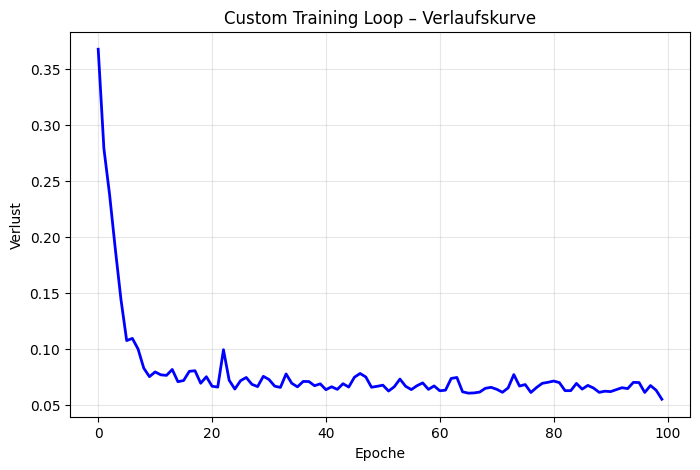

In [1]:
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 3: Mehrschichtige Netze (MLP)
# Niveau: Experten
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement a custom TensorFlow training loop with GradientTape
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

# TensorFlow Konstanten erstellen
X_train_tf = tf.constant(X_train, dtype=tf.float32)
y_train_tf = tf.constant(y_train, dtype=tf.float32)
X_test_tf  = tf.constant(X_test, dtype=tf.float32)

modell = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
verlust_fn = tf.keras.losses.BinaryCrossentropy()

@tf.function
def trainings_schritt(X_batch, y_batch):
    """Ein Trainingsschritt mit GradientTape"""
    with tf.GradientTape() as tape:
        vorhersagen = modell(X_batch, training=True)
        verlust = verlust_fn(y_batch, vorhersagen)
    gradienten = tape.gradient(verlust, modell.trainable_variables)
    optimizer.apply_gradients(zip(gradienten, modell.trainable_variables))
    return verlust

epochen = 100
batch_groesse = 32
verlauf = []

for epoche in range(epochen):
    # Daten mischen
    perm = tf.random.shuffle(tf.range(len(X_train)))
    X_shuffled = tf.gather(X_train_tf, perm)
    y_shuffled = tf.gather(y_train_tf, perm)
    
    batch_verluste = []
    for start in range(0, len(X_train), batch_groesse):
        X_b = X_shuffled[start:start+batch_groesse]
        y_b = y_shuffled[start:start+batch_groesse]
        v = trainings_schritt(X_b, y_b)
        batch_verluste.append(float(v))
    
    epoch_verlust = np.mean(batch_verluste)
    verlauf.append(epoch_verlust)
    if (epoche+1) % 20 == 0:
        print(f"Epoche {epoche+1:3d}/{epochen}: Verlust={epoch_verlust:.4f}")

y_pred = (modell.predict(X_test_tf, verbose=0) > 0.5).flatten()
print(f"\nTestgenauigkeit: {(y_pred == y_test).mean():.2%}")

plt.figure(figsize=(8,5))
plt.plot(verlauf, 'b-', linewidth=2)
plt.title('Custom Training Loop – Verlaufskurve'); plt.xlabel('Epoche'); plt.ylabel('Verlust')
plt.grid(True, alpha=0.3)
plt.show()


### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_moons` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_moons(n_samples=500, noise=0.15, ra...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `tf.keras.layers.Dense(16, activation='relu', na...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `modell.compile(optimizer='adam', loss='binary_c...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `for name in ['schicht_1', 'schicht_2']` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


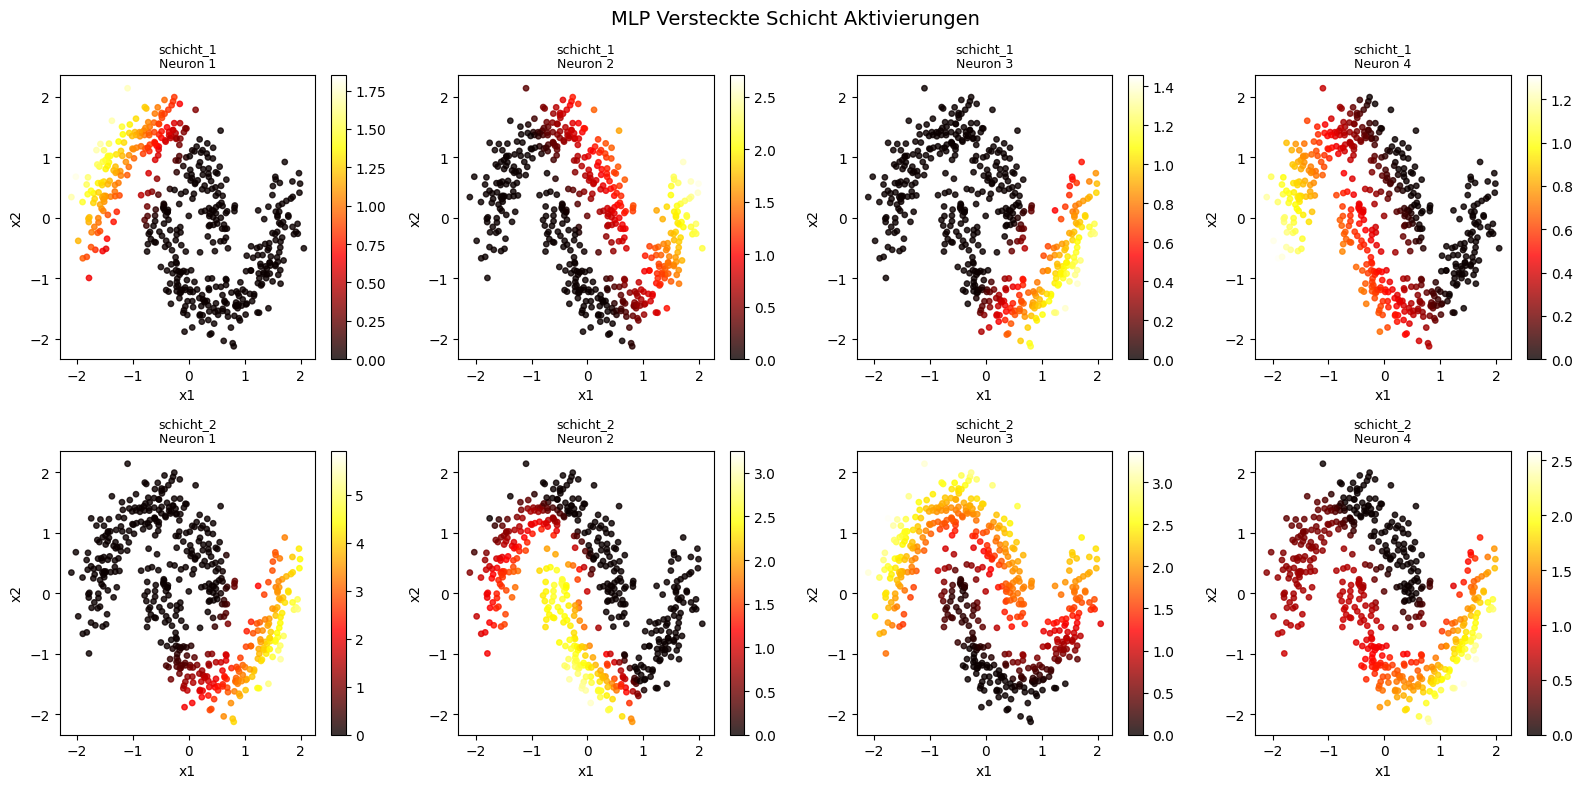

In [2]:
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 3: Mehrschichtige Netze (MLP)
# Niveau: Experten
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Visualize hidden layer activations of a trained MLP
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_moons(n_samples=500, noise=0.15, random_state=42)
scaler = StandardScaler(); X_std = scaler.fit_transform(X)

# MLP trainieren
modell = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu', name='schicht_1'),
    tf.keras.layers.Dense(8,  activation='relu', name='schicht_2'),
    tf.keras.layers.Dense(1,  activation='sigmoid', name='ausgabe'),
])
modell.compile(optimizer='adam', loss='binary_crossentropy')
modell.fit(X_std, y, epochs=200, verbose=0)

# Hilfsmodelle für Aktivierungsextraktion
aktivierungs_modelle = {
    name: tf.keras.Model(inputs=modell.input, outputs=modell.get_layer(name).output)
    for name in ['schicht_1', 'schicht_2']
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('MLP Versteckte Schicht Aktivierungen', fontsize=14)

for zeile, (schicht_name, akt_modell) in enumerate(aktivierungs_modelle.items()):
    aktivierungen = akt_modell.predict(X_std, verbose=0)
    n_neuronen = aktivierungen.shape[1]
    
    for j in range(min(4, n_neuronen)):
        ax = axes[zeile, j]
        sc = ax.scatter(X_std[:,0], X_std[:,1], c=aktivierungen[:,j], 
                        cmap='hot', s=15, alpha=0.8)
        ax.set_title(f'{schicht_name}\nNeuron {j+1}', fontsize=9)
        ax.set_xlabel('x1'); ax.set_ylabel('x2')
        plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()


### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_classification` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_classification(n_samples=2000, n_fe...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `def residual_block(x, einheiten):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `x = tf.keras.layers.Dense(einheiten, activation...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `if shortcut.shape[-1] != einheiten:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `return x` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `resnet.compile(optimizer='adam', loss='binary_c...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print(f"\nResNet Testgenauigkeit: {resnet.evalu...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


Model: "SimpleResNet"


__________________________________________________________________________________________________


 Layer (type)                   Output Shape         Param #     Connected to                     


 input_3 (InputLayer)           [(None, 20)]         0           []                               


 dense_3 (Dense)                (None, 64)           1344        ['input_3[0][0]']                


...

 dense_11 (Dense)               (None, 1)            33          ['activation_2[0][0]']           


Total params: 23,233


Trainable params: 23,233


Non-trainable params: 0


__________________________________________________________________________________________________


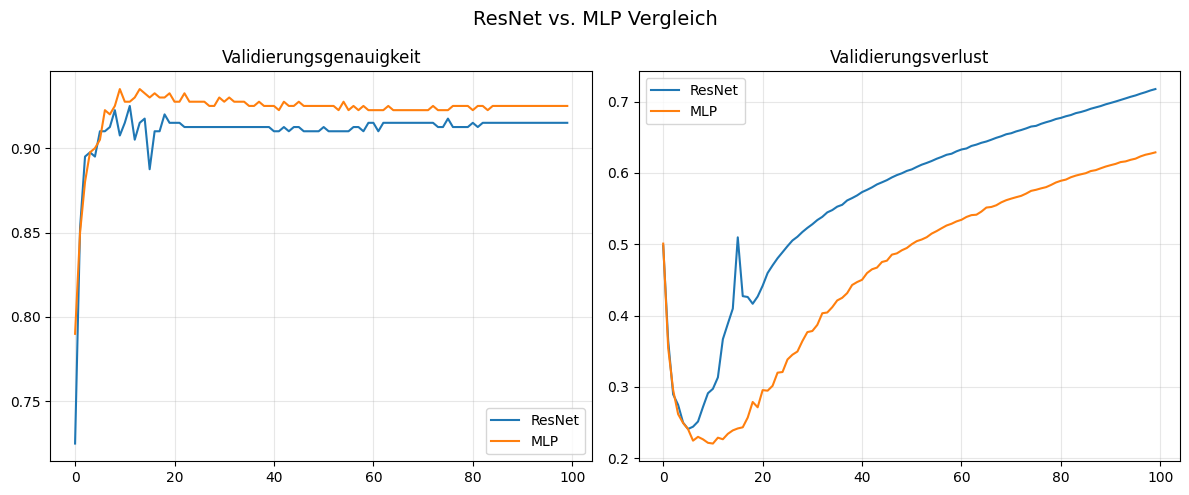


ResNet Testgenauigkeit: 91.50%
MLP Testgenauigkeit:    92.50%


In [3]:
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 3: Mehrschichtige Netze (MLP)
# Niveau: Experten
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement a simple ResNet with skip connections
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

def residual_block(x, einheiten):
    """Residual Block mit Skip Connection"""
    shortcut = x
    x = tf.keras.layers.Dense(einheiten, activation='relu')(x)
    x = tf.keras.layers.Dense(einheiten)(x)
    
    # Skip Connection: Projektion falls Dimensionen unterschiedlich
    if shortcut.shape[-1] != einheiten:
        shortcut = tf.keras.layers.Dense(einheiten)(shortcut)
    
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

# ResNet aufbauen
eingabe = tf.keras.Input(shape=(X_train.shape[1],))
x = tf.keras.layers.Dense(64, activation='relu')(eingabe)
x = residual_block(x, 64)
x = residual_block(x, 64)
x = residual_block(x, 32)
ausgabe = tf.keras.layers.Dense(1, activation='sigmoid')(x)

resnet = tf.keras.Model(eingabe, ausgabe, name='SimpleResNet')
resnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
resnet.summary()

history_res = resnet.fit(X_train, y_train, validation_data=(X_test, y_test),
                          epochs=100, batch_size=64, verbose=0)

# Vergleich mit normalem MLP
mlp = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mlp = mlp.fit(X_train, y_train, validation_data=(X_test, y_test),
                       epochs=100, batch_size=64, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_res.history['val_accuracy'], label='ResNet')
axes[0].plot(history_mlp.history['val_accuracy'], label='MLP')
axes[0].set_title('Validierungsgenauigkeit'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_res.history['val_loss'], label='ResNet')
axes[1].plot(history_mlp.history['val_loss'], label='MLP')
axes[1].set_title('Validierungsverlust'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('ResNet vs. MLP Vergleich', fontsize=14)
plt.tight_layout()
plt.show()
print(f"\nResNet Testgenauigkeit: {resnet.evaluate(X_test, y_test, verbose=0)[1]:.2%}")
print(f"MLP Testgenauigkeit:    {mlp.evaluate(X_test, y_test, verbose=0)[1]:.2%}")
